# Live Cell Painting → AnnData

Live Cell Painting of Huh7 cells treated with silver nanoparticles ([`cpg0039`](https://broadinstitute.github.io/cellpainting-gallery/)). Profiles sit one directory shallower than the usual layout, one file per batch rather than per plate.

One observation is a well, one variable is a CellProfiler feature.
Well-level profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*_normalized_negcon_feature_select.csv" \
  s3://cellpainting-gallery/cpg0039-garcia-fossa-livecellpainting/unicamp/workspace/profiles/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0039-garcia-fossa-livecellpainting/profiles").expanduser()

In [2]:
files = sorted(PROFILES.glob("*/*.csv"))
print(f"{len(files)} plates")

5 plates


In [3]:
adata = cpio.read_profiles(
    files, index_columns=["batch", "Plate", "Well"], path_columns={"batch": 1}, on_column_mismatch="intersect"
)
adata

AnnData object with n_obs × n_vars = 536 × 82
    obs: 'Plate', 'Well', 'plate_map_name', 'control_type', 'batch'
    layers: None (.X)

In [4]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
adata = cpio.drop_extreme_features(adata)
adata = cpio.drop_constant_features(adata)


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


cpio.categorize(adata, present(["Plate", "plate_map_name", "control_type", "batch"]))
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Cytoplasm_AreaShape_CentralMoment_1_0,cytoplasm,areashape,NaN,NaN,0
Cytoplasm_AreaShape_HuMoment_1,cytoplasm,areashape,NaN,NaN,0
Cytoplasm_AreaShape_HuMoment_2,cytoplasm,areashape,NaN,NaN,0
Cytoplasm_AreaShape_NormalizedMoment_0_3,cytoplasm,areashape,NaN,NaN,0
Cytoplasm_AreaShape_NormalizedMoment_2_3,cytoplasm,areashape,NaN,NaN,0
...,...,...,...,...,...
Nuclei_AreaShape_Zernike_8_6,nuclei,areashape,NaN,NaN,0
Nuclei_AreaShape_Zernike_9_1,nuclei,areashape,NaN,NaN,0
Nuclei_AreaShape_Zernike_9_3,nuclei,areashape,NaN,NaN,0


## Sanity checks

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present(["control_type", "plate_map_name"]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

536 wells x 82 features
non-finite: 0 | max|x|: 109.7

control_type:
control_type
<NA>      346
trt        96
negcon     94

plate_map_name:
plate_map_name
platemap_agnp      180
platemap_dili      177
layout_day1         60
layout_day2         60
platemap_131035     35
platemap_134819     24


In [6]:
adata.write_h5ad(PROFILES.parent / "garcia_fossa_live.h5ad")

## UMAP

The profiles are already normalized, so they enter PCA unscaled.

In [7]:
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?
Above 1 means the covariate explains part of the embedding.

In [8]:
cpio.neighbour_enrichment(adata, present(["batch", "Plate", "plate_map_name", "control_type"]))

,observed,baseline,ratio
covariate,,,
batch,0.663,0.426,1.557
Plate,0.331,0.105,3.146
plate_map_name,0.453,0.253,1.789
control_type,0.615,0.500,1.230


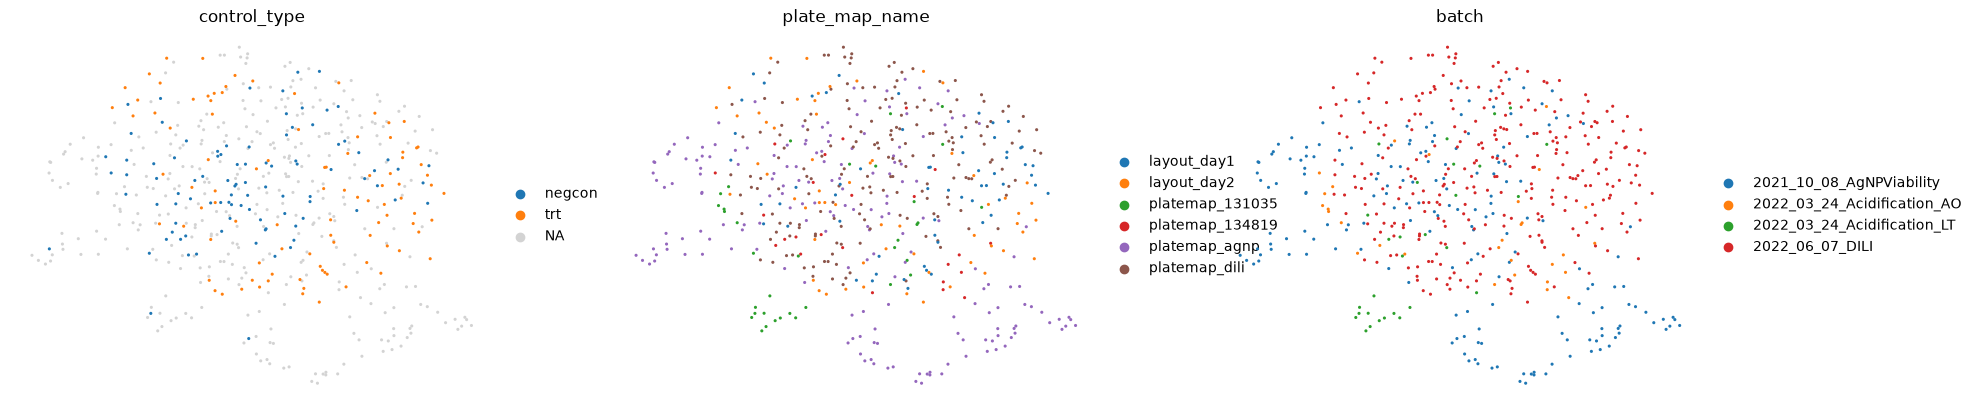

In [9]:
sc.pl.umap(adata, color=present(["control_type", "plate_map_name", "batch"])[:3], ncols=3, frameon=False, size=20)